In [3]:
import json
import numpy as np
import ast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from metrics_clean import compute_zadu_metrics
from utils import get_pareto_front
import os

## Load all the data

### Ground Truth and Returns embeddings

In [4]:
#get trajectories for morld from json files
#only if they end with .json
returns = get_pareto_front("trajectories/morld/mo-halfcheetah-v4_100steps", pareto_size=80)
all_t_emb_e200 = []
path=f'trajectories/morld/mo-halfcheetah-v4_100steps/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e200_ts100.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e200.append(t_emb)

all_t_emb_e200 = np.array(all_t_emb_e200)


all_t_emb_e100 = []
path=f'trajectories/morld/mo-halfcheetah-v4_100steps/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e100_ts100.json'
with open(path, "r") as f:
    embedding = json.load(f)
for policy in embedding:
    t_emb = np.array(policy['T_Embedding'])
    all_t_emb_e100.append(t_emb)

all_t_emb_e100 = np.array(all_t_emb_e100)


In [3]:
returns

array([[ 1.62762009e+00, -3.49798577e+00],
       [ 1.65594967e+02, -6.03967593e+01],
       [ 1.41687146e+00, -3.30056036e+00],
       [ 1.58888125e+02, -5.54826703e+01],
       [ 1.62353056e+02, -5.60594555e+01],
       [ 1.62113014e+00, -3.38018610e+00],
       [ 1.62560177e+02, -6.01943781e+01],
       [ 1.96928101e+00, -3.50616259e+00],
       [ 1.68746607e+02, -6.12147387e+01],
       [ 2.00785421e+02, -6.94313755e+01],
       [ 2.00326152e+00, -3.50651620e+00],
       [ 1.97079348e+02, -6.83492142e+01],
       [ 2.72398822e+00, -3.52554732e+00],
       [ 3.24533094e+00, -3.75459626e+00],
       [ 2.14487478e+02, -7.01144785e+01],
       [ 2.26287078e+02, -7.50226077e+01],
       [ 2.18356644e+02, -7.20560472e+01],
       [ 3.21866258e+00, -3.53624313e+00],
       [ 3.86513116e+00, -3.82765054e+00],
       [ 2.29393015e+02, -7.81508986e+01],
       [ 5.05466640e+00, -3.87261190e+00],
       [ 5.42914572e+00, -4.10200691e+00],
       [ 6.19609117e+00, -4.27870981e+00],
       [ 2.

## Trustworthiness and Continuity

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("\n--- RAW METRICS ---")
print("Returns vs E100:", compute_zadu_metrics(returns, all_t_emb_e100))
print(" Returns vs E200:", compute_zadu_metrics(returns, all_t_emb_e200))
print("E100 vs E200:", compute_zadu_metrics(all_t_emb_e100, all_t_emb_e200))



--- RAW METRICS ---
ZADU metrics computed successfully
Returns vs E100: [{'trustworthiness': 0.9077614379084966, 'continuity': 0.9313725490196079}, {'mrre_false': 0.9038297872340426, 'mrre_missing': 0.9261702127659575}]
ZADU metrics computed successfully
 Returns vs E200: [{'trustworthiness': 0.9119281045751635, 'continuity': 0.9407679738562091}, {'mrre_false': 0.9099468085106384, 'mrre_missing': 0.9362234042553192}]
ZADU metrics computed successfully
E100 vs E200: [{'trustworthiness': 0.9562908496732027, 'continuity': 0.9553921568627451}, {'mrre_false': 0.9521808510638298, 'mrre_missing': 0.9524468085106385}]


### Visualize embeddings

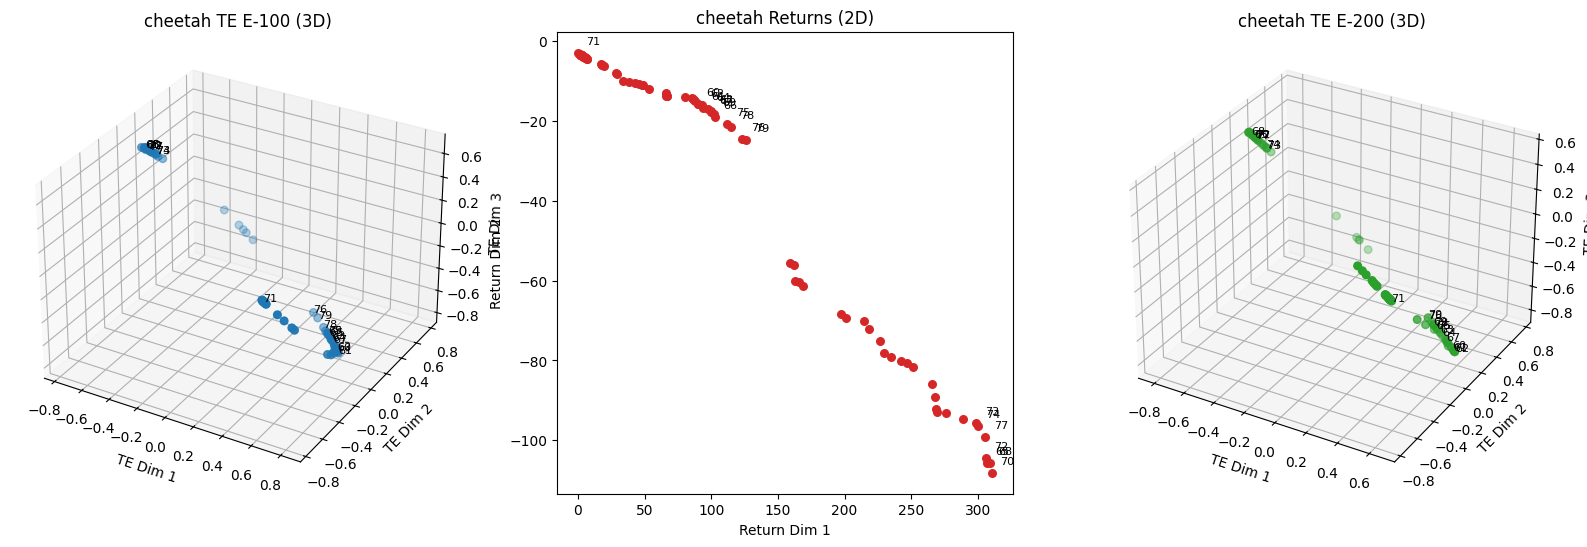

In [6]:
# Full visualization: 3D TE (e100), 2D Returns, 3D TE (e200).
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ensure arrays
returns = np.asarray(returns)
all_t_e100 = np.asarray(all_t_emb_e100)
all_t_e200 = np.asarray(all_t_emb_e200)

# indices to annotate (original indices) — adjust as needed
start, end = 60, 79
sel = np.arange(start, end + 1)
sel = sel[sel < len(returns)]

fig = plt.figure(figsize=(20, 6))

# TE E100 3D (all points)
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(all_t_e100[:, 0], all_t_e100[:, 1], all_t_e100[:, 2], c='tab:blue', s=30)
ax1.set_title('cheetah TE E-100 (3D)')
ax1.set_xlabel('TE Dim 1'); ax1.set_ylabel('TE Dim 2'); ax1.set_zlabel('TE Dim 3')
# annotate only selected indices
for idx in sel:
    if idx < len(all_t_e100):
        x, y, z = all_t_e100[idx]
        ax1.text(x, y, z, str(int(idx)), fontsize=8, color='k')

# Returns 2D (all points)
ax2 = fig.add_subplot(132)
ax2.scatter(returns[:, 0], returns[:, 1], c='tab:red', s=30)
ax2.set_title('cheetah Returns (2D)')
ax2.set_xlabel('Return Dim 1'); ax2.set_ylabel('Return Dim 2')
# compute small offset based on data span
if returns.shape[1] >= 2:
    dx = np.ptp(returns[:, 0]) * 0.02 if np.ptp(returns[:, 0]) > 0 else 0.01
    dy = np.ptp(returns[:, 1]) * 0.02 if np.ptp(returns[:, 1]) > 0 else 0.01
else:
    dx = dy = 0.01
for idx in sel:
    if idx < len(returns):
        x, y = returns[idx, 0], returns[idx, 1]
        ax2.text(x + dx, y + dy, str(int(idx)), fontsize=8, color='k')

# TE E200 3D (all points)
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(all_t_e200[:, 0], all_t_e200[:, 1], all_t_e200[:, 2], c='tab:green', s=30)
ax3.set_title('cheetah TE E-200 (3D)')
ax3.set_xlabel('TE Dim 1'); ax3.set_ylabel('TE Dim 2'); ax3.set_zlabel('TE Dim 3')
for idx in sel:
    if idx < len(all_t_e200):
        x, y, z = all_t_e200[idx]
        ax3.text(x, y, z, str(int(idx)), fontsize=8, color='k')

In [8]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- assume you already have these numpy arrays ---
# returns: shape (N, 2)
# embeddings: shape (N, 3) or (N, D)
# example for testing:
# returns = np.random.rand(50, 2)
# embeddings = np.random.rand(50, 3)

# --- Sort lexicographically and keep mapping ---
sort_idx = np.lexsort(returns.T)
sorted_pf = returns[sort_idx]

# --- Build dataframe ---
df = pd.DataFrame({
    "obj1": sorted_pf[:, 0],
    "obj2": sorted_pf[:, 1],
    "rank": np.arange(len(sort_idx)),     # new ordered index
    "orig_idx": sort_idx                  # original index
})

# --- 2D Pareto frontier visualization ---
fig2d = go.Figure()

fig2d.add_trace(go.Scatter(
    x=df["obj1"],
    y=df["obj2"],
    mode="markers+text",
    text=df["rank"].astype(str),
    textposition="top center",
    marker=dict(size=8, color="crimson"),
    customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
    hovertemplate=(
        "new idx (rank)=%{customdata[0]}<br>"
        "original idx=%{customdata[1]}<br>"
        "obj1=%{x:.3f}<br>"
        "obj2=%{y:.3f}<extra></extra>"
    ),
    name="Pareto (sorted)"
))

fig2d.update_layout(
    width=800, height=600,
    title="Sorted Pareto Frontier (labels = new ordered indices)",
    xaxis_title="Objective 1",
    yaxis_title="Objective 2"
)

fig2d.write_html("cheetah.html")
fig2d.show()


# --- 3D embeddings visualization aligned with sorted indices ---
emb3 = all_t_e100[:, :3]           # take first 3 dims if more
emb3_sorted = emb3[sort_idx]       # reorder same as returns

fig3d = go.Figure()

# points labeled by new sorted index
fig3d.add_trace(go.Scatter3d(
    x=emb3_sorted[:, 0],
    y=emb3_sorted[:, 1],
    z=emb3_sorted[:, 2],
    mode="markers+text",
    text=df["rank"].astype(str),
    textposition="top center",
    marker=dict(
        size=4,
        color=df["rank"],
        colorscale="Viridis",
        colorbar=dict(title="rank")
    ),
    customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
    hovertemplate=(
        "new idx (rank)=%{customdata[0]}<br>"
        "original idx=%{customdata[1]}<br>"
        "x=%{x:.3f}<br>"
        "y=%{y:.3f}<br>"
        "z=%{z:.3f}<extra></extra>"
    ),
    name="Embeddings (sorted)"
))


fig3d.update_layout(
    width=900, height=700,
    title="3D Embeddings (aligned with sorted Pareto indices)",
    scene=dict(
        xaxis_title="Embedding dim 1",
        yaxis_title="Embedding dim 2",
        zaxis_title="Embedding dim 3"
    )
)

fig3d.write_html("cheetah_3d_embeddings.html")
fig3d.show()


In [10]:
sort_idx = np.lexsort(returns.T)
sorted_pf = returns[sort_idx]
sorted_pf

array([[ 3.10749088e+02, -1.08129619e+02],
       [ 3.09297234e+02, -1.05705136e+02],
       [ 3.06524346e+02, -1.05606519e+02],
       [ 3.06230301e+02, -1.04402964e+02],
       [ 3.05569807e+02, -9.91022567e+01],
       [ 3.00102688e+02, -9.64291446e+01],
       [ 2.98815216e+02, -9.57212063e+01],
       [ 2.88703087e+02, -9.46577098e+01],
       [ 2.76403276e+02, -9.30666813e+01],
       [ 2.69570057e+02, -9.27907122e+01],
       [ 2.68723914e+02, -9.22225360e+01],
       [ 2.67835383e+02, -8.92691003e+01],
       [ 2.65254871e+02, -8.59670323e+01],
       [ 2.51036667e+02, -8.17517583e+01],
       [ 2.46794738e+02, -8.05375902e+01],
       [ 2.42246988e+02, -8.01745829e+01],
       [ 2.35032934e+02, -7.92371178e+01],
       [ 2.29393015e+02, -7.81508986e+01],
       [ 2.26287078e+02, -7.50226077e+01],
       [ 2.18356644e+02, -7.20560472e+01],
       [ 2.14487478e+02, -7.01144785e+01],
       [ 2.00785421e+02, -6.94313755e+01],
       [ 1.97079348e+02, -6.83492142e+01],
       [ 1.

## Lipschitz Histograms


Computing Lipschitz constant between policy 0 and 1
2.825950643170885
0.05473284613695094
Lipshitz: 0.019367941287020293
Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [-0.73669219  0.1191003   0.54888034]) to 1 ([ 309.29723363 -105.70513637], [-0.72439218  0.07812975  0.58302426]): 0.019367941287020293, d_obj: 2.825950643170885, d_emb: 0.05473284613695094
Computing Lipschitz constant between policy 1 and 2
2.7746412039307944
0.0321086330809462
Lipshitz: 0.011572174822264716
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [-0.72439218  0.07812975  0.58302426]) to 2 ([ 306.52434554 -105.60651863], [-0.73245245  0.10236257  0.56356233]): 0.011572174822264716, d_obj: 2.7746412039307944, d_emb: 0.0321086330809462
Computing Lipschitz constant between policy 2 and 3
1.2389537465973897
0.03696263414217238
Lipshitz: 0.02983374822803918
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [-0.73245245  0.10236257  0.56356233]) to 3 ([ 306.23030094 -10

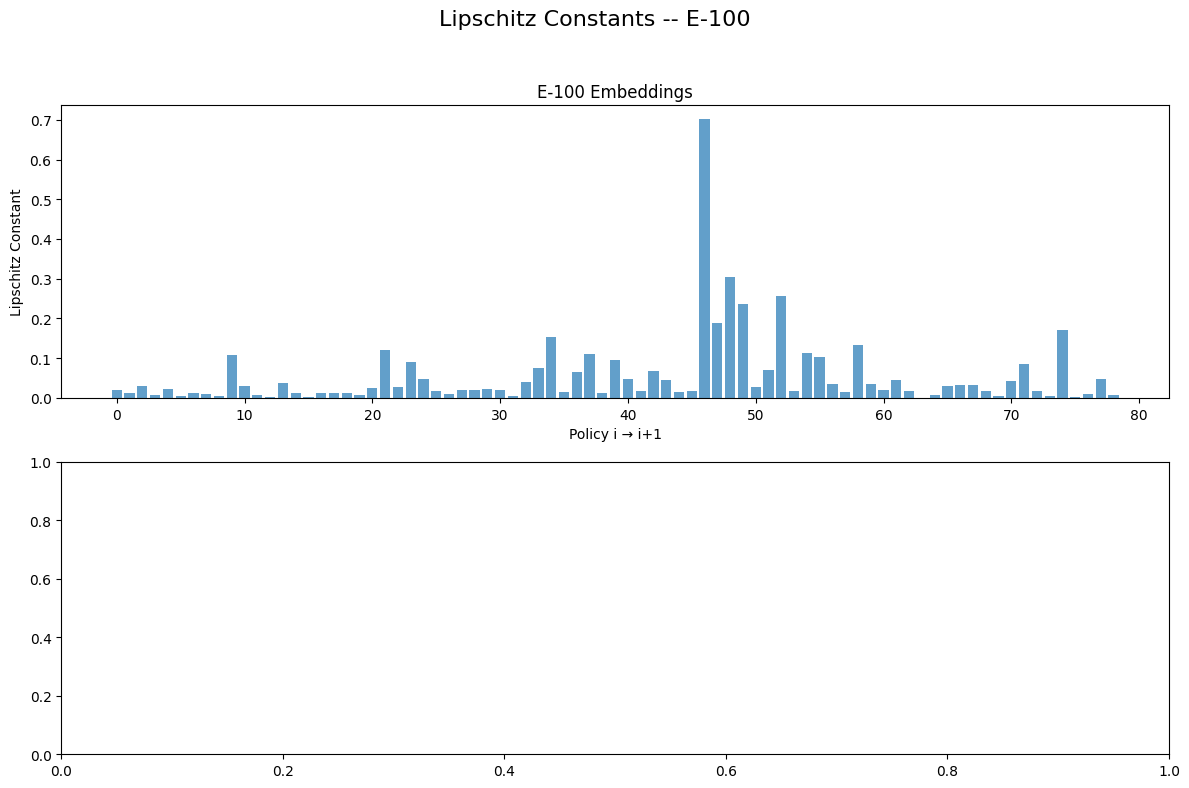

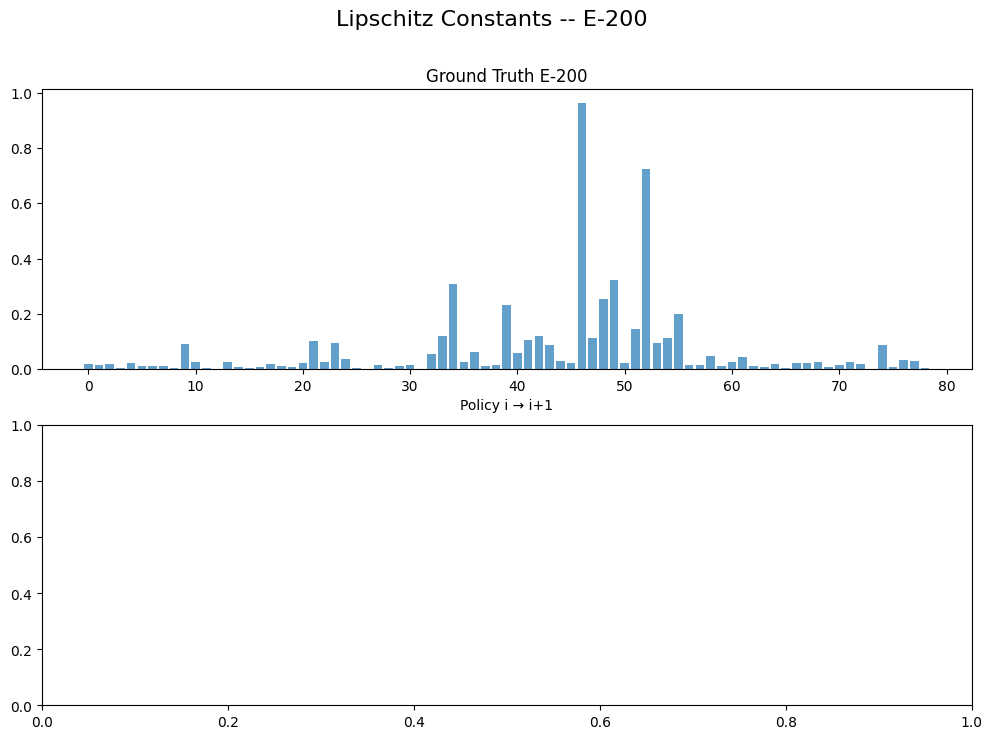

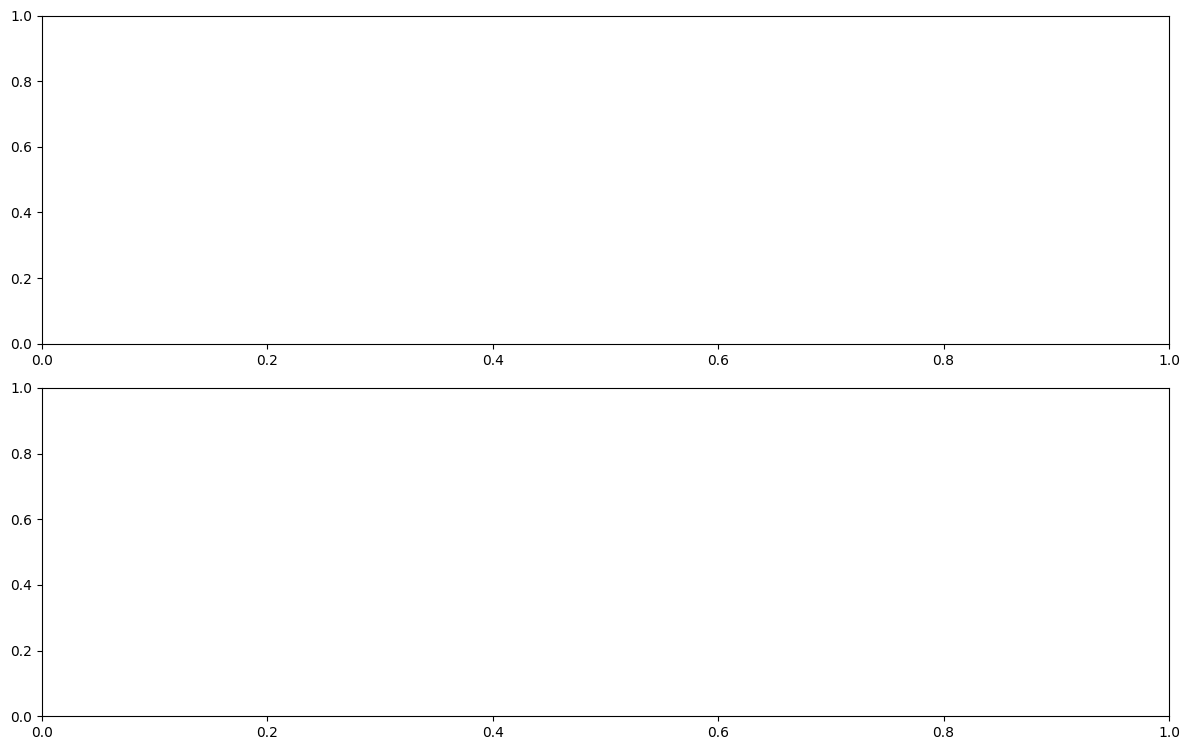

In [11]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns

# Compute Lipschitz constants
def compute_lipschitz_constants(pareto_frontier: np.ndarray, embeddings: np.ndarray) -> np.ndarray:
    """
    Compute pairwise Lipschitz constants between consecutive points
    in the Pareto frontier and embedding space.

    Args:
        pareto_frontier: (n_points, d_obj) array of objective values
        embeddings: (n_points, d_emb) array of embeddings

    Returns:
        lipschitz_constants: (n_points-1,) array of Lipschitz constants
    """
    # Lexicographic sort: np.lexsort expects keys in reverse order
    sort_idx = np.lexsort(pareto_frontier.T)
    sorted_pf = pareto_frontier[sort_idx]
    sorted_emb = embeddings[sort_idx]

    lipschitz_constants = []
    for i in range(len(sorted_pf) - 1):
        print(f"Computing Lipschitz constant between policy {i} and {i+1}")
        d_obj = np.linalg.norm(sorted_pf[i+1] - sorted_pf[i])
        print(d_obj)
        d_emb = np.linalg.norm(sorted_emb[i+1] - sorted_emb[i])
        print(d_emb)
        lipschitz_constants.append(d_emb / d_obj)
        print(f'Lipshitz: {d_emb/d_obj}')

        print(f"Lipschitz constant for policy {i} ({sorted_pf[i]}, {sorted_emb[i]}) to {i+1} ({sorted_pf[i+1]}, {sorted_emb[i+1]}): {lipschitz_constants[-1]}, d_obj: {d_obj}, d_emb: {d_emb}")

    return np.array(lipschitz_constants)



lipschitz_constants_gt = compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_e100)
lipschitz_constants_gt_concave = compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_e200)


import matplotlib.pyplot as plt
import numpy as np

# Create 2x1 grid for each figure
fig, axs = plt.subplots(2, figsize=(12, 8))
fig2, axs2 = plt.subplots(2, figsize=(12, 8))
fig3, axs3 = plt.subplots(2, figsize=(12, 8))

# --- Plot 1: Left-Right ---
fig.suptitle("Lipschitz Constants -- E-100", fontsize=16)
axs[0].bar(np.arange(len(lipschitz_constants_gt)), lipschitz_constants_gt, alpha=0.7)
axs[0].set_title("E-100 Embeddings")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")


fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
fig.savefig("lipschitz_left_right.png", dpi=300, bbox_inches='tight')  # ✅ Save first figure

# --- Plot 2: Concave ---
fig2.suptitle("Lipschitz Constants -- E-200", fontsize=16)
axs2[0].bar(np.arange(len(lipschitz_constants_gt_concave)), lipschitz_constants_gt_concave, alpha=0.7)
axs2[0].set_title("Ground Truth E-200")
axs2[0].set_xlabel("Policy i → i+1")


fig3.tight_layout(rect=[0, 0, 1, 0.95])
fig3.savefig("lipschitz_smooth.png", dpi=300, bbox_inches='tight')  # ✅ Save third figure

plt.show()



